In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import layers, models
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)
import importlib
import models.controlcnn as controlcnn
importlib.reload(controlcnn)
import metrics.util_metrics as metrics
importlib.reload(metrics)



GPUs: []


In [ ]:
#data

batch_size = 16
img_size = (224, 224)
directory = 'C:\\Users\\frank\\OneDrive\\Documents\\vsCodeProjects\\cytology\\data'
seed = 100

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=img_size,
    validation_split=0.2,
    subset='training',
    seed=seed
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=img_size,
    validation_split=0.2,
    subset='validation',
    seed=seed
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

def dataset_to_numpy(ds):
    imgs, labels = [], []
    for x_batch, y_batch in ds.as_numpy_iterator():
        imgs.append(x_batch)
        labels.append(y_batch)
    imgs = np.vstack(imgs)
    labels = np.hstack(labels)
    return imgs, labels

X_train, y_train = dataset_to_numpy(train_ds)
X_val, y_val = dataset_to_numpy(val_ds)

print(X_train.shape, y_train.shape)

Found 600 files belonging to 3 classes.
Using 480 files for training.
Found 600 files belonging to 3 classes.
Using 120 files for validation.
(480, 224, 224, 3) (480,)


In [55]:


#Build
X_train = X_train / 255.0
X_val = X_val / 255.0
model = controlcnn.build_control_cnn(input_shape=X_train.shape[1:], num_classes=len(np.unique(y_train)))

c:\Users\frank\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Train
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.3417 - loss: 1.1222 - val_accuracy: 0.3000 - val_loss: 1.1141
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 328ms/step - accuracy: 0.3417 - loss: 1.1071 - val_accuracy: 0.3000 - val_loss: 1.1073
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 262ms/step - accuracy: 0.3417 - loss: 1.1034 - val_accuracy: 0.3000 - val_loss: 1.1056
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.3417 - loss: 1.1023 - val_accuracy: 0.3000 - val_loss: 1.1045
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 201ms/step - accuracy: 0.3417 - loss: 1.1018 - val_accuracy: 0.3000 - val_loss: 1.1040
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.3417 - loss: 1.1029 - val_accuracy: 0.3000 - val_loss: 1.1052
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.3417 - loss: 1.1021 - val_accuracy: 0.3000 - val_loss: 1.1042
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.3417 - loss: 1.1013 - val_accuracy: 0

In [58]:
#optimize
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_control_cnn.h5",
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.3158 - loss: 1.1003

30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.3417 - loss: 1.0994 - val_accuracy: 0.3000 - val_loss: 1.1015
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.3417 - loss: 1.0996 - val_accuracy: 0.3000 - val_loss: 1.1012
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.3417 - loss: 1.0995 - val_accuracy: 0.3000 - val_loss: 1.1011
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.3417 - loss: 1.0992 - val_accuracy: 0.3000 - val_loss: 1.1012
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 183ms/step - accuracy: 0.3417 - loss: 1.0994 - val_accuracy: 0.3000 - val_loss: 1.1016
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - accuracy: 0.3417 - loss: 1.0993 - val_accuracy: 0.3000 - val_loss: 1.1012
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.3417 - loss: 1.0992 - val_accuracy: 0.3000 - val_loss: 1.1013
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.3417 - loss: 1.0992 - val_accuracy: 0.3000 - val_

In [61]:
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = y_val

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


Accuracy: 0.3
F1 Score: 0.13846153846153847
AUC: 0.5


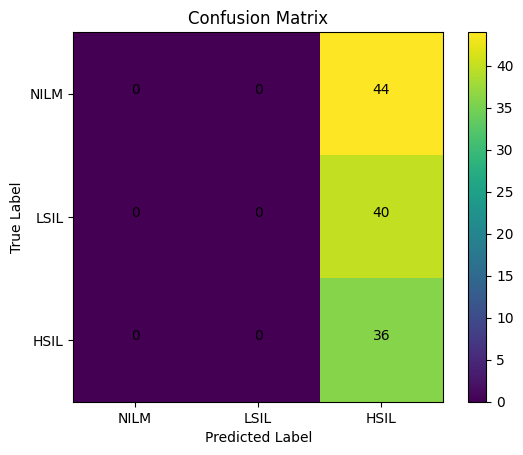

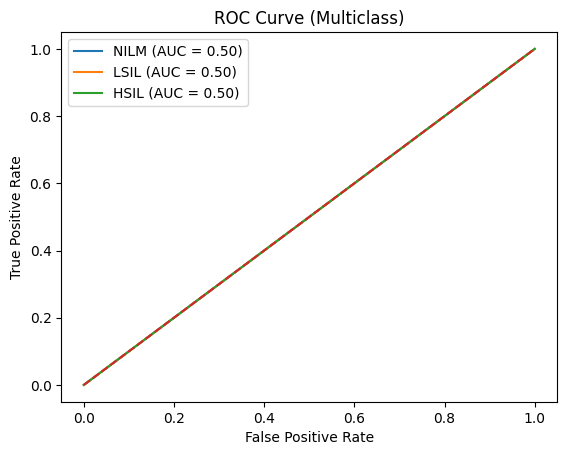

{0: 0.5, 1: 0.5, 2: 0.5}

In [ ]:
#results 
acc = metrics.compute_accuracy(y_true, y_pred)
f1 = metrics.compute_f1(y_true, y_pred)
auc_score = metrics.compute_auc(y_true, y_pred_probs, num_classes=3)

print("Accuracy:", acc)
print("F1 Score:", f1)
print("AUC:", auc_score)

class_names = ["NILM", "LSIL", "HSIL"]

metrics.plot_confusion_matrix(y_true, y_pred, class_names)
metrics.plot_roc_multiclass(y_true, y_pred_probs, 3, class_names)